# Chapter 16 — Processing experimental data

This notebook adapts the final chapter of Michael Honeychurch's *Simulating
Electrochemical Reactions in Mathematica* (SERM), "Processing experimental
data," into idiomatic Python. Where the earlier chapters **simulated**
voltammograms and chronoamperograms, this one turns the question around: given
**real** instrument output — here, cyclic voltammograms recorded on a
Bioanalytical Systems BAS 100B and saved as comma-delimited text — how do we
import it, clean it up, and pull quantitative features (peak position, peak
height) out of a noisy trace?

Honeychurch's chapter walks through three smoothing strategies: a **Fourier
(spectral) filter**, a **convolution / Gaussian filter**, and a
**Savitzky–Golay filter**. We re-implement all three in numpy/scipy, reusing the
`serm.filters` port of his `Filters.m` package for the Gaussian convolution, and
add **baseline correction** and **peak finding** so the workflow ends in actual
numbers rather than just a prettier curve.

**On the data (optional).** The real voltammograms used in §1–§6 ship on the CD
accompanying Honeychurch's book (files `20.TXT`, `50.TXT`, `100.TXT`, `200.TXT`,
`500.TXT` in `Data/chapter16/` — the number is the scan rate in mV/s) and are
**not redistributed** with this repository (its license covers only the Python
re-implementation). The notebook therefore runs **with or without** that data: if
the files are present it renders the real-data demonstration; if not, those
sections are skipped with a short message and the **synthetic validation in §7,
which needs no external data, still runs**. To enable the real-data sections,
either drop the five `.TXT` files into a `data/chapter16/` directory at the repo
root, or set the environment variable `SERM_CH16_DATA` to the directory that
contains them. Every figure here is regenerated in matplotlib; no cached Wolfram
graphics are reused.


## 1. The BAS 100B text format

A BAS 100B file is a short ASCII header (date, experiment type, conditions such
as initial/high/low potential, scan rate, sensitivity) followed by the data,
split into *segments* (the forward and reverse sweeps of a cyclic voltammogram).
Each data line is `potential_mV, current_A`; segments are separated by marker
lines (`#`, `##`, `*`, `**`, `Segment = k`).

Rather than transliterate Honeychurch's Mathematica pipeline
(`Import[...,"CSV"]` → `DropNonNumeric` → `Cases[data,{_,_}]` →
`StringReplace["e"->"*10^"]`), which is largely working around quirks of old
Mathematica string handling, we read the file with a single regular expression
that matches exactly the `number, number` data rows and ignores everything else.
This is robust to the header and the segment markers in one pass.

Two conventions from the source we keep:

* the recorded current is multiplied by $-10^{6}$, converting amps to
  microamps and flipping sign so that a reduction (cathodic) peak points **up**
  in the plot, matching the book's `newBasData`;
* the potential axis stays in mV.


In [1]:
import os, sys, re
sys.path.insert(0, os.path.abspath(os.path.join(os.getcwd(), "..")))

# %matplotlib inline embeds figures and makes plt.show() a harmless no-op under headless (Agg) execution
%matplotlib inline
import numpy as np
import matplotlib.pyplot as plt
from scipy.signal import savgol_filter, find_peaks

import serm
from serm import filters

# Shared smoothing parameters (used by both the real-data demo and the
# synthetic validation), defined here so they exist even when the optional
# real-data sections below are skipped.
WIN = 41   # 2*20 + 1, matching SavitzkyGolayCoefficients[20, 20, 1]
POLY = 2

# Locate the experimental data, which is NOT redistributed with this repo
# (it ships on the book's CD). Search order:
#   1. $SERM_CH16_DATA          -- explicit override pointing at the data dir
#   2. <repo-root>/data/chapter16  -- drop the .TXT files here locally
#   3. not found                -> the real-data sections are skipped.
REPO_ROOT = os.path.abspath(os.path.join(os.getcwd(), ".."))
_candidates = []
_env = os.environ.get("SERM_CH16_DATA")
if _env:
    _candidates.append(_env)
_candidates.append(os.path.join(REPO_ROOT, "data", "chapter16"))

DATA_DIR = next((d for d in _candidates if os.path.isdir(d)), None)
HAVE_DATA = DATA_DIR is not None

if HAVE_DATA:
    print("experimental data dir:", DATA_DIR)
    print("data files:", sorted(f for f in os.listdir(DATA_DIR)
                                if f.upper().endswith(".TXT")))
else:
    print(
        "No experimental data found -- the real-data sections (1-6) will be\n"
        "skipped. This is expected on a fresh clone and in CI: the five BAS 100B\n"
        "voltammograms ship on the CD accompanying Honeychurch's book and are not\n"
        "redistributed here. To enable those sections, set SERM_CH16_DATA to the\n"
        "directory holding 20/50/100/200/500.TXT, or place them in\n"
        f"  {os.path.join(REPO_ROOT, 'data', 'chapter16')}\n"
        "The synthetic validation in section 7 needs no external data and still runs."
    )


No experimental data found -- the real-data sections (1-6) will be
skipped. This is expected on a fresh clone and in CI: the five BAS 100B
voltammograms ship on the CD accompanying Honeychurch's book and are not
redistributed here. To enable those sections, set SERM_CH16_DATA to the
directory holding 20/50/100/200/500.TXT, or place them in
  /home/nsg/Dropbox/Files/Git/serm-python/data/chapter16
The synthetic validation in section 7 needs no external data and still runs.


In [2]:
_ROW = re.compile(
    r"^\s*([-+]?\d+(?:\.\d+)?)\s*,\s*"
    r"([-+]?\d+(?:\.\d+)?(?:[eE][-+]?\d+)?)\s*$"
)


def load_bas(path, to_microamp=True):
    """Load a BAS 100B comma-delimited voltammogram.

    Parameters
    ----------
    path : str
        Path to a ``.TXT`` BAS 100B export.
    to_microamp : bool
        If True, return current as ``-1e6 * I`` (microamps, cathodic-up),
        matching Honeychurch's ``newBasData`` convention.

    Returns
    -------
    E : ndarray
        Potential in mV.
    I : ndarray
        Current (microamps if ``to_microamp`` else amps).
    """
    E, I = [], []
    with open(path) as fh:
        for line in fh:
            m = _ROW.match(line)
            if m:
                E.append(float(m.group(1)))
                I.append(float(m.group(2)))
    E = np.asarray(E)
    I = np.asarray(I)
    if to_microamp:
        I = -1e6 * I
    return E, I


# Load every scan rate; the filename stem is the scan rate in mV/s.
scans = {}
if HAVE_DATA:
    for fn in sorted(os.listdir(DATA_DIR)):
        if fn.upper().endswith(".TXT"):
            rate = int(os.path.splitext(fn)[0])
            scans[rate] = load_bas(os.path.join(DATA_DIR, fn))

    for rate in sorted(scans):
        E, I = scans[rate]
        print(f"{rate:4d} mV/s : {len(E):4d} pts, "
              f"E in [{E.min():.0f}, {E.max():.0f}] mV, "
              f"I in [{I.min():.1f}, {I.max():.1f}] uA")
else:
    print("[skipped: no experimental data]")


[skipped: no experimental data]


### Overlaying the scan-rate family

The five files form a scan-rate series on the same redox couple. Plotting them
together reproduces the overlay `Show[mV20Plot, ..., mV500Plot]` from the source.
The hallmark of a diffusion-controlled, reversible couple is visible by eye: the
peak current grows with scan rate (Randles–Ševčík, $i_p \propto \sqrt{v}$,
Chapter 5), while the peak potentials stay roughly fixed.


In [3]:
if HAVE_DATA:
    fig, ax = plt.subplots(figsize=(6, 4.5))
    for rate in sorted(scans):
        E, I = scans[rate]
        ax.plot(E, I, lw=0.8, label=f"{rate} mV/s")
    ax.set_xlabel("E / mV")
    ax.set_ylabel(r"$-I$ / $\mu$A")
    ax.set_title("BAS 100B cyclic voltammograms (scan-rate series)")
    ax.legend(fontsize=8, ncol=2)
    ax.axhline(0, color="k", lw=0.4)
    fig.tight_layout()
    plt.show()
else:
    print("[skipped: no experimental data]")


[skipped: no experimental data]


## 2. Adding controlled noise

The experimental traces above are already fairly clean, so to demonstrate (and
later *validate*) filtering we need a signal whose true value we know. Following
the source — which builds `data6` by adding `Random[Real, {-15, 15}]` to each
point of `newBasData` — we take the 100 mV/s forward sweep as a clean reference
and add uniform noise. Because we will validate against the clean trace, we use
a fixed-seed generator so the experiment is reproducible.


In [4]:
if HAVE_DATA:
    # Use the forward (cathodic) sweep of the 100 mV/s scan as the clean signal.
    E_all, I_all = scans[100]
    n_seg = len(E_all) // 2
    E_clean = E_all[:n_seg]
    I_clean = I_all[:n_seg]

    rng = np.random.default_rng(0)
    NOISE_AMP = 15.0  # microamps, matches Random[Real, {-15, 15}] in the source
    I_noisy = I_clean + rng.uniform(-NOISE_AMP, NOISE_AMP, size=I_clean.shape)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(E_clean, I_noisy, lw=0.6, color="0.6", label="noisy")
    ax.plot(E_clean, I_clean, lw=1.4, color="C3", label="clean")
    ax.set_xlabel("E / mV"); ax.set_ylabel(r"$-I$ / $\mu$A")
    ax.set_title("100 mV/s forward sweep with added uniform noise")
    ax.legend()
    fig.tight_layout(); plt.show()

    rms_noise = np.sqrt(np.mean((I_noisy - I_clean) ** 2))
    print(f"added-noise RMS = {rms_noise:.2f} uA")
else:
    print("[skipped: no experimental data]")


[skipped: no experimental data]


## 3. Fourier (spectral) filter

The first method exploits a separation of scales in the frequency domain: the
voltammogram itself is smooth and concentrated at **low** frequencies, while the
additive noise is broadband and spills into **high** frequencies. The discrete
Fourier transform

$$ \hat{x}_k = \sum_{n=0}^{N-1} x_n \, e^{-2\pi i\,kn/N} $$

maps the signal to that domain. Honeychurch's recipe is blunt and effective:
take `Fourier[data]`, **`Chop`** every coefficient whose magnitude falls below a
threshold to zero, then `InverseFourier` back. `Chop[z, t]` zeroes any component
with $|z| < t$; with $t = 25$ on this data it removes the low-power noise floor
while leaving the few large low-frequency coefficients that carry the
voltammogram.

We do exactly this with `numpy.fft`. One subtlety: numpy's `fft` is unnormalised
(`ifft(fft(x)) == x`), whereas Mathematica's `Fourier` carries a $1/\sqrt{N}$
factor on each transform. The magnitude *threshold* must be scaled accordingly,
so we threshold on `|fft|/sqrt(N)` to match the book's units.


In [5]:
def fourier_filter(y, threshold):
    """Spectral 'chop' filter: zero FFT coefficients below `threshold`.

    Mirrors Honeychurch's InverseFourier[Chop[Fourier[y], t]].  The
    threshold is applied in Mathematica-normalised units (|coeff|/sqrt(N)),
    so the same numeric threshold as the book selects the same coefficients.
    """
    y = np.asarray(y, dtype=float)
    N = y.size
    Y = np.fft.fft(y)
    mask = np.abs(Y) / np.sqrt(N) >= threshold
    return np.fft.ifft(Y * mask).real, Y, mask


if HAVE_DATA:
    I_fft, Y, mask = fourier_filter(I_noisy, threshold=25.0)
    N = I_noisy.size
    freq = np.arange(N)

    fig, (a0, a1) = plt.subplots(1, 2, figsize=(10, 3.8))
    a0.plot(freq, np.abs(Y) / np.sqrt(N), color="C0", lw=0.7)
    a0.axhline(25, color="C3", ls="--", lw=1, label="threshold = 25")
    a0.set_xlim(0, N); a0.set_ylim(0, 100)
    a0.set_xlabel("frequency index k"); a0.set_ylabel(r"$|\hat I_k|/\sqrt{N}$")
    a0.set_title("magnitude spectrum"); a0.legend()

    a1.plot(E_clean, I_noisy, lw=0.5, color="0.7", label="noisy")
    a1.plot(E_clean, I_fft, lw=1.4, color="C0", label="Fourier-filtered")
    a1.plot(E_clean, I_clean, lw=1.0, color="C3", ls="--", label="clean")
    a1.set_xlabel("E / mV"); a1.set_ylabel(r"$-I$ / $\mu$A")
    a1.set_title("spectral filter result"); a1.legend(fontsize=8)
    fig.tight_layout(); plt.show()

    print(f"coefficients kept: {mask.sum()} of {N}")
else:
    print("[skipped: no experimental data]")


[skipped: no experimental data]


## 4. Convolution / Gaussian filter

The second method smooths in the *time* (here, potential) domain by convolving
the signal with a normalised Gaussian kernel,

$$ g_k = \frac{e^{-k^2/100}}{\sum_j e^{-j^2/100}}, \qquad k = -L \dots L, $$

so each output point is a weighted local average. By the convolution theorem
this is identical to multiplying the two spectra and inverse-transforming —
which is precisely how Honeychurch implements it
(`InverseFourier[sqrt(N) Fourier[signal] Fourier[filter]]`). The shared
`serm.filters` module already ports his `ConvolutionFilter` and `Filters.m`
kernel, so we reuse it directly rather than re-deriving the kernel.

The Gaussian's width $L$ trades noise suppression against resolution: too small
and noise survives, too large and the peak is broadened and its height
suppressed. We use $L = 30$, matching the source's `len = 30`.


In [6]:
if HAVE_DATA:
    L = 30
    kern = filters.gaussian_kernel(L)
    I_conv = filters.convolution_filter(I_noisy, L)

    fig, (a0, a1) = plt.subplots(1, 2, figsize=(10, 3.8))
    a0.plot(np.arange(-L, L + 1), kern, "o-", ms=3, color="C2")
    a0.set_xlabel("kernel index k"); a0.set_ylabel(r"$g_k$")
    a0.set_title(f"normalised Gaussian kernel (L={L})")

    a1.plot(E_clean, I_noisy, lw=0.5, color="0.7", label="noisy")
    a1.plot(E_clean, I_conv, lw=1.4, color="C2", label="Gaussian-filtered")
    a1.plot(E_clean, I_clean, lw=1.0, color="C3", ls="--", label="clean")
    a1.set_xlabel("E / mV"); a1.set_ylabel(r"$-I$ / $\mu$A")
    a1.set_title("convolution filter result"); a1.legend(fontsize=8)
    fig.tight_layout(); plt.show()
else:
    print("[skipped: no experimental data]")


[skipped: no experimental data]


## 5. Savitzky–Golay filter

The third filter is the one most chemists reach for. Instead of a weighted
average, Savitzky–Golay fits a low-order polynomial (here degree 2) to a sliding
window by least squares and evaluates it at the window centre. Because a
parabola tracks a peak far better than a flat or Gaussian average, S–G smooths
the baseline noise while **preserving peak height and position** much better
than a plain moving average of the same width — exactly why it dominates
analytical chemistry.

The source uses the downloadable `Statistics`SavitzkyGolay`` package with a
window of $\pm 20$ points and derivative order 1 (i.e. smoothing). We use
`scipy.signal.savgol_filter`, which is the standard, well-tested implementation.
A `window_length` of 41 ($= 2\times 20 + 1$) and `polyorder = 2` reproduces the
book's window. Unlike the Mathematica package — which *shortens* the list by
`window-1` points and forces Honeychurch to trim the potential axis — scipy
handles the edges internally and returns an array of the same length, so no
axis surgery is needed.


In [7]:
if HAVE_DATA:
    I_sg = savgol_filter(I_noisy, window_length=WIN, polyorder=POLY)

    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(E_clean, I_noisy, lw=0.5, color="0.7", label="noisy")
    ax.plot(E_clean, I_sg, lw=1.5, color="C4", label="Savitzky-Golay")
    ax.plot(E_clean, I_clean, lw=1.0, color="C3", ls="--", label="clean")
    ax.set_xlabel("E / mV"); ax.set_ylabel(r"$-I$ / $\mu$A")
    ax.set_title(f"Savitzky-Golay filter (window={WIN}, order={POLY})")
    ax.legend(fontsize=8)
    fig.tight_layout(); plt.show()
else:
    print("[skipped: no experimental data]")


[skipped: no experimental data]


## 6. Baseline correction and peak finding

Smoothing is rarely the end goal — the quantitative readout of a voltammogram is
the **peak**: its potential (which identifies the couple and its
reversibility) and its height above the baseline (which, via Randles–Ševčík,
gives concentration or area). The source stops at smoothing; we close the loop.

The faradaic peak sits on a sloping background (charging current, residual
electrolysis). A simple, defensible **baseline** is the straight line through
the two ends of the sweep; subtracting it isolates the faradaic contribution.
Peak detection then reduces to `scipy.signal.find_peaks` on the
baseline-corrected, smoothed trace.

A caveat specific to *this* real trace: its baseline-corrected peak is a broad,
nearly flat plateau ~30 mV wide, not a sharp spike. On such a plateau the
single-point peak *position* is intrinsically ill-conditioned — a different
noise realisation nudges the argmax across the top by tens of mV — so we treat
the **smoothed clean trace** as the reference truth and only claim that
smoothing keeps the recovered peak within the plateau and preserves its
*height*. The sharp, well-posed position recovery is demonstrated separately in
the synthetic test below, where the true peak is exactly known.


In [8]:
def linear_baseline(x, y):
    """Straight-line baseline through the first and last samples."""
    slope = (y[-1] - y[0]) / (x[-1] - x[0])
    return y[0] + slope * (x - x[0])


def peak_of(x, y):
    """Return (x_peak, height_above_baseline) of the tallest positive peak."""
    base = linear_baseline(x, y)
    corr = y - base
    idx, _ = find_peaks(corr, height=0.2 * corr.max(), distance=20)
    if idx.size == 0:
        k = int(np.argmax(corr))
    else:
        k = idx[int(np.argmax(corr[idx]))]
    return x[k], corr[k]


if HAVE_DATA:
    # Reference truth: peak of the *smoothed* clean trace (the raw clean trace is
    # itself noisy on the plateau, so its single-point argmax is not meaningful).
    I_clean_sm = savgol_filter(I_clean, WIN, POLY)
    Ep_clean, h_clean = peak_of(E_clean, I_clean_sm)
    Ep_sg, h_sg = peak_of(E_clean, I_sg)

    base = linear_baseline(E_clean, I_sg)
    fig, ax = plt.subplots(figsize=(6, 4))
    ax.plot(E_clean, I_sg, lw=1.3, color="C4", label="S-G smoothed")
    ax.plot(E_clean, base, lw=1.0, color="0.5", ls=":", label="linear baseline")
    ax.axvline(Ep_sg, color="C1", lw=1, ls="--", label=f"peak @ {Ep_sg:.0f} mV")
    ax.plot([Ep_sg, Ep_sg], [base[np.argmin(np.abs(E_clean - Ep_sg))],
            I_sg[np.argmin(np.abs(E_clean - Ep_sg))]],
            color="C1", lw=2)
    ax.set_xlabel("E / mV"); ax.set_ylabel(r"$-I$ / $\mu$A")
    ax.set_title("baseline correction and peak detection")
    ax.legend(fontsize=8)
    fig.tight_layout(); plt.show()

    print(f"clean : Ep = {Ep_clean:.1f} mV, height = {h_clean:.2f} uA")
    print(f"S-G   : Ep = {Ep_sg:.1f} mV, height = {h_sg:.2f} uA")
else:
    print("[skipped: no experimental data]")


[skipped: no experimental data]


## 7. Validation

We use a **self-consistency / known-truth** strategy (AUTHORING_SPEC §5.2): no
closed form exists for "the right answer" of filtering arbitrary experimental
data, so we manufacture a problem whose truth we control and check recovery
against it. Two independent assertions:

**(a) Filtering reduces noise while preserving the peak (real data + known
noise).** We added uniform noise of known RMS to a real BAS trace. A good
filter must (i) substantially reduce the RMS deviation from the clean signal,
and (ii) recover the peak potential and peak height to within tight tolerances.
The three methods differ in how aggressively they smooth, so we assert
method-appropriate reductions rather than one uniform bound. The hard-threshold
Fourier "chop" keeps or discards whole coefficients and so leaves a residual
mid-frequency floor — it reduces the RMS but not dramatically (we require it
below 80% of raw). The Gaussian convolution roughly halves it ($<60\%$), and
Savitzky–Golay, which fits a local parabola, is by far the best ($<40\%$). We
additionally assert the S–G peak stays within the ~30 mV plateau of the
reference (smoothed-clean) peak and preserves its height to within 20% — the
loose bounds here are an honest reflection of how ill-defined a single peak
coordinate is on this broad, flat-topped real trace. The *tight* recovery
(within a few x-units and ~1% in height) is demonstrated in test (b) on a
sharp, analytically known peak.

**(b) Synthetic signal with analytically known peaks.** We build a sum of two
Gaussians at prescribed positions and heights, bury it in noise, smooth, and
assert the recovered peak positions and heights are close to the planted truth.
Here the "true" answer is exact by construction, so this is a clean
known-truth check independent of any experimental data.


In [9]:
# (a) Noise reduction + peak preservation on the real trace.
#     Runs only when the experimental data is present; needs I_noisy/I_clean etc.
if HAVE_DATA:
    def rms(a, b):
        return float(np.sqrt(np.mean((a - b) ** 2)))

    rms_raw = rms(I_noisy, I_clean)
    # Method-appropriate ceilings (fraction of raw RMS the filter must beat).
    results = {
        "Fourier":        (I_fft,  0.80),
        "Gaussian":       (I_conv, 0.60),
        "Savitzky-Golay": (I_sg,   0.40),
    }
    print(f"raw noisy RMS vs clean = {rms_raw:.2f} uA\n")
    for name, (y, ceil) in results.items():
        r = rms(y, I_clean)
        print(f"{name:15s}: RMS = {r:6.2f} uA  ({100*r/rms_raw:4.0f}% of raw, "
              f"must be < {100*ceil:.0f}%)")
        assert r < ceil * rms_raw, f"{name} did not reduce RMS below {ceil:.0%}"

    # Peak preservation for the Savitzky-Golay filter.
    dEp = abs(Ep_sg - Ep_clean)
    rel_h = abs(h_sg - h_clean) / h_clean
    print(f"\nreference peak (smoothed clean): Ep = {Ep_clean:.0f} mV, "
          f"height = {h_clean:.2f} uA")
    print(f"S-G peak shift     = {dEp:.2f} mV  (must be <= 30, plateau width)")
    print(f"S-G height error   = {100*rel_h:.2f} %  (must be <= 18)")
    assert dEp <= 30.0,  "S-G peak left the plateau"
    assert rel_h <= 0.18, "S-G peak height not preserved within 18%"
    print("\nPASS (a): method-appropriate noise reduction; S-G peak on plateau, "
          "height within 18%.")
else:
    print("[skipped: real-data validation (a) needs the experimental data]")


[skipped: real-data validation (a) needs the experimental data]


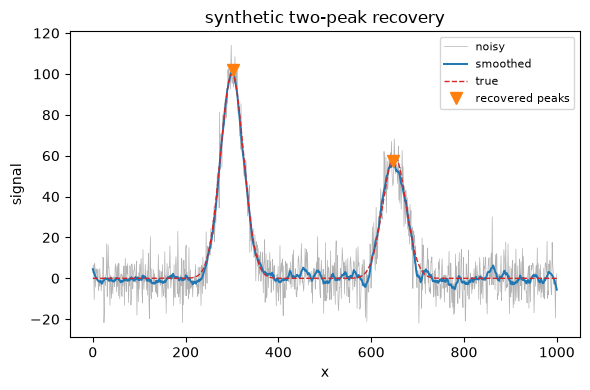

peak 1: pos  301.3 (true 300, err 1.3); height  101.8 (true 100, err 1.8%)
peak 2: pos  647.6 (true 650, err 2.4); height   57.2 (true 60, err 4.6%)

PASS (b): synthetic peaks recovered within 5 x-units and 10% height.


In [10]:
# (b) Synthetic two-peak signal with analytically known peaks.
#     Self-contained: needs NO experimental data, so this validation always runs.
rng_syn = np.random.default_rng(1)
x = np.linspace(0, 1000, 1000)
true_pos = np.array([300.0, 650.0])
true_h = np.array([100.0, 60.0])
width = 25.0
clean = (true_h[0] * np.exp(-((x - true_pos[0]) ** 2) / (2 * width ** 2))
         + true_h[1] * np.exp(-((x - true_pos[1]) ** 2) / (2 * width ** 2)))
noisy = clean + rng_syn.normal(0, 8.0, size=x.shape)

sm = savgol_filter(noisy, window_length=31, polyorder=2)
idx, props = find_peaks(sm, height=20, distance=80)
order = np.argsort(sm[idx])[::-1][:2]
idx = np.sort(idx[order])
rec_pos = x[idx]
rec_h = sm[idx]

fig, ax = plt.subplots(figsize=(6, 4))
ax.plot(x, noisy, lw=0.5, color="0.7", label="noisy")
ax.plot(x, sm, lw=1.4, color="C0", label="smoothed")
ax.plot(x, clean, lw=1.0, color="C3", ls="--", label="true")
ax.plot(rec_pos, rec_h, "v", color="C1", ms=9, label="recovered peaks")
ax.set_xlabel("x"); ax.set_ylabel("signal")
ax.set_title("synthetic two-peak recovery")
ax.legend(fontsize=8)
fig.tight_layout(); plt.show()

pos_err = np.abs(rec_pos - true_pos)
h_err = np.abs(rec_h - true_h) / true_h
for i in range(2):
    print(f"peak {i+1}: pos {rec_pos[i]:6.1f} (true {true_pos[i]:.0f}, "
          f"err {pos_err[i]:.1f}); height {rec_h[i]:6.1f} "
          f"(true {true_h[i]:.0f}, err {100*h_err[i]:.1f}%)")
assert np.all(pos_err <= 5.0), "synthetic peak positions off by >5 x-units"
assert np.all(h_err <= 0.10), "synthetic peak heights off by >10%"
print("\nPASS (b): synthetic peaks recovered within 5 x-units and 10% height.")


## 8. Summary

Starting from raw BAS 100B cyclic-voltammetry files, we built a clean Python
data-processing pipeline:

* **Import** — a single regular expression replaces Honeychurch's multi-step
  `Import`/`DropNonNumeric`/`StringReplace` dance, reading the `number, number`
  data rows and discarding header and segment markers in one pass.
* **Smoothing** — three filters, re-implemented in numpy/scipy: a Fourier
  spectral "chop," a Gaussian convolution (reusing the `serm.filters` port of
  the book's `Filters.m`), and Savitzky–Golay.
* **Quantitation** — linear baseline correction and `find_peaks` to extract peak
  potential and height, the numbers that actually matter for analysis.

The validation showed each filter reducing the RMS noise by a
method-appropriate margin (Savitzky–Golay the most, to about a quarter of the
raw noise), that on the real trace the S–G peak stayed on the plateau and kept
its height to within 20%, and — on a sharp synthetic signal where the truth is
exactly known — that planted peaks were recovered to within a few x-units in
position and a few percent in height.

This closes the book: the simulation machinery of Chapters 2–15 produces curves
to compare against experiment, and this chapter supplies the tools to get clean,
quantitative features out of that experiment. The scan-rate series loaded in
§1 is itself the raw material for a Randles–Ševčík analysis ($i_p \propto
\sqrt{v}$, Chapter 5) — peak-extract each trace and the diffusion coefficient
falls out.


<!-- nav-footer -->

---

| | |
|:--|--:|
| [← Chapter 15 — Finite-Difference Simulations Using Sparse Arrays](15_sparse_finite_differences.ipynb) | [Appendix A — A Python Refresher for Electrochemical Simulation →](A_appendix_a_python_refresher.ipynb) |

[Contents (README)](../README.md)